In [122]:
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt


In [142]:
iris = sns.load_dataset("iris")
X = iris.iloc[:,0:4].values
n = X.shape[0] #n de amostras
c = 3 #cluesters
m = 2 #grau de fuzzyness
seed = 67
iris.head(150)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


# Criando a matriz de pertinência

In [124]:
def inicializar_pertinencia(n, c, seed=67):
  np.random.seed(seed)
  U = np.random.rand(n, c)
  U = U / np.sum(U, axis=1, keepdims=True) # normalizando para ficar no maximo 1 em cada linha
  return U

# Calculando centroides

In [125]:
def calcular_centroides(X, U, m):

    n_clusters = U.shape[1]
    n_features = X.shape[1]

    V = np.zeros((n_clusters, n_features))

    for j in range(n_clusters):

        pesos = U[:, j] ** m

        numerador = np.sum(pesos[:, None] * X, axis=0)
        denominador = np.sum(pesos)

        V[j] = numerador / denominador

    return V

# Calculando as distancias

In [126]:
def calcular_distancias(X,V):

  dist = cdist(X, V, metric="euclidean")

  return dist

# Atualizando a matriz de pertinencia com as distancias

In [127]:
def atualizar_pertinencia(dist, m):

    n = dist.shape[0]
    c = dist.shape[1]

    U = np.zeros((n,c))

    for i in range(n):
        for j in range(c):
            soma = 0
            for k in range(c):
                soma += (dist[i,j] / dist[i,k]) ** (2/(m-1))
            U[i,j] = 1 / soma

    return U

# Loop do algoritmo

In [128]:
def loop_fuzzy(X, c, m, max_iter=50, erro=0.00001):

    U = inicializar_pertinencia(len(X), c)

    for iteracao in range(max_iter):

        U_antigo = U.copy()

        V = calcular_centroides(X, U, m)

        dist = calcular_distancias(X, V)

        U = atualizar_pertinencia(dist, m)

        if np.linalg.norm(U - U_antigo) < erro:
            break

    return U, V

In [129]:
U, V = loop_fuzzy(X, c=3, m=2)
#print(U)

In [143]:
df = pd.DataFrame(U, columns=["Cluster 1", "Cluster 2", "Cluster 3"])
print(df.round(4))

     Cluster 1  Cluster 2  Cluster 3
0       0.0011     0.0023     0.9966
1       0.0075     0.0166     0.9759
2       0.0064     0.0138     0.9798
3       0.0101     0.0225     0.9674
4       0.0018     0.0038     0.9945
..         ...        ...        ...
145     0.8824     0.1064     0.0113
146     0.4667     0.5075     0.0258
147     0.8314     0.1564     0.0121
148     0.7894     0.1890     0.0216
149     0.3913     0.5818     0.0269

[150 rows x 3 columns]


# Plotando graficos

In [131]:
iris2 = iris[iris["species"] != "setosa"] #filtrando para a parte 3 do trabalho
X2 = iris2[["petal_length", "petal_width"]].values

In [132]:
U2, V2 = loop_fuzzy(X2, c=2, m=2) #rodando novamente, agora apenas com 2 especies e 2 clusters
df2 = pd.DataFrame(U2, columns=["Cluster 1", "Cluster 2"])
print(df2.round(4))

    Cluster 1  Cluster 2
0      0.1224     0.8776
1      0.0444     0.9556
2      0.3247     0.6753
3      0.0229     0.9771
4      0.0852     0.9148
..        ...        ...
95     0.8744     0.1256
96     0.6553     0.3447
97     0.8654     0.1346
98     0.9491     0.0509
99     0.7104     0.2896

[100 rows x 2 columns]


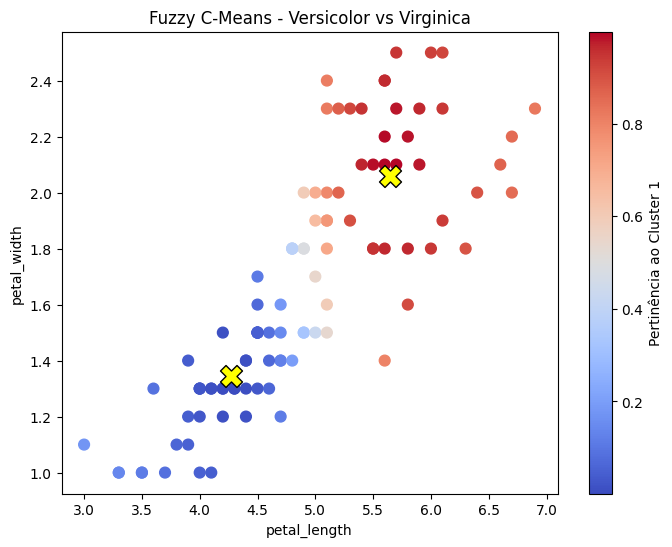

In [136]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(X2[:,0], X2[:,1], c=U2[:,0], cmap="coolwarm", s=60)
plt.scatter(V2[:,0], V2[:,1], marker="X", s=250, edgecolor="black", color="yellow", label="Centroides")

plt.xlabel("petal_length")
plt.ylabel("petal_width")
plt.title("Fuzzy C-Means - Versicolor vs Virginica")

cbar = plt.colorbar(scatter)
cbar.set_label("Pertinência ao Cluster 1")

plt.show()